In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:/Users/hp/OneDrive/Desktop/WiDS/salary_dataset.csv")

Q1

In [3]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 12000 non-null  int64  
 1   gender              12000 non-null  object 
 2   education_level     11885 non-null  object 
 3   years_experience    11868 non-null  float64
 4   job_title           12000 non-null  object 
 5   performance_score   11746 non-null  float64
 6   industry            12000 non-null  object 
 7   city                11940 non-null  object 
 8   previous_companies  12000 non-null  int64  
 9   remote_worker       12000 non-null  object 
 10  salary              12000 non-null  float64
dtypes: float64(3), int64(2), object(6)
memory usage: 1.0+ MB


,age,years_experience,performance_score,previous_companies,salary
count,12000.000000,11868.000000,11746.000000,12000.000000,12000.000000
mean,35.693083,15.731530,3.752103,1.984417,105862.030433
std,7.741977,8.204885,0.775138,1.397797,28250.776445
min,21.000000,0.000000,1.000000,0.000000,31728.080000
25%,30.000000,9.900000,3.200000,1.000000,88133.922500
50%,36.000000,15.550000,3.800000,2.000000,103028.190000
75%,41.000000,21.300000,4.300000,3.000000,120510.670000
max,65.000000,45.000000,5.000000,12.000000,497044.771908


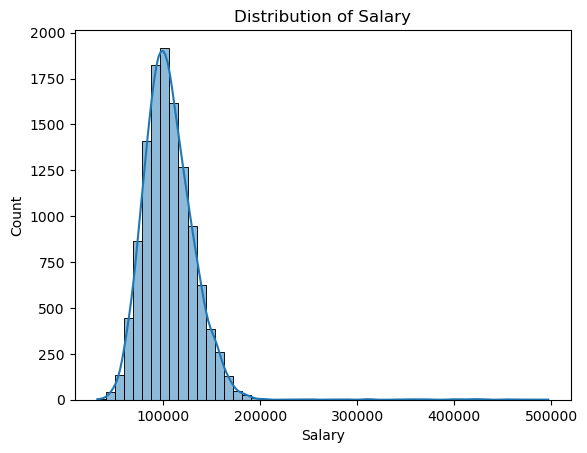

In [4]:
#Univariate analysis (histograms)
plt.figure()
sns.histplot(df['salary'], bins=50, kde=True)
plt.title("Distribution of Salary")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.show()

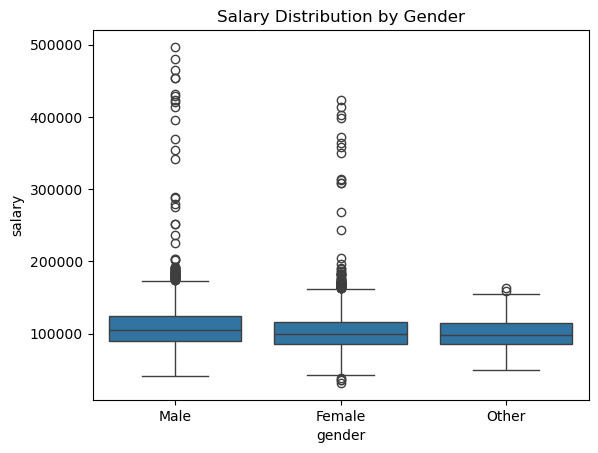

In [5]:
#Salary by gender
plt.figure()
sns.boxplot(x='gender', y='salary', data=df)
plt.title("Salary Distribution by Gender")
plt.show()

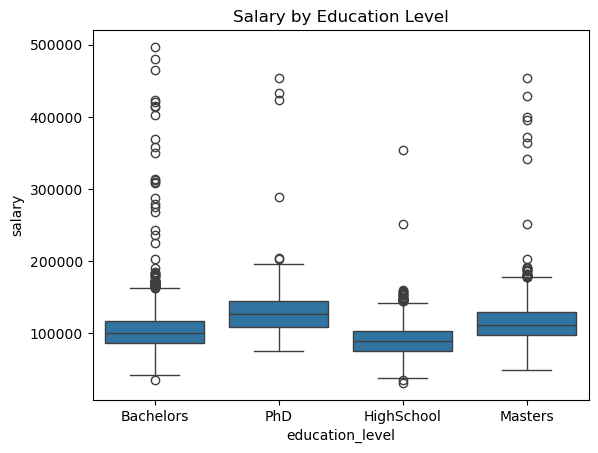

In [6]:
#Salary by education level
plt.figure()
sns.boxplot(x='education_level', y='salary', data=df)
plt.title("Salary by Education Level")
plt.show()

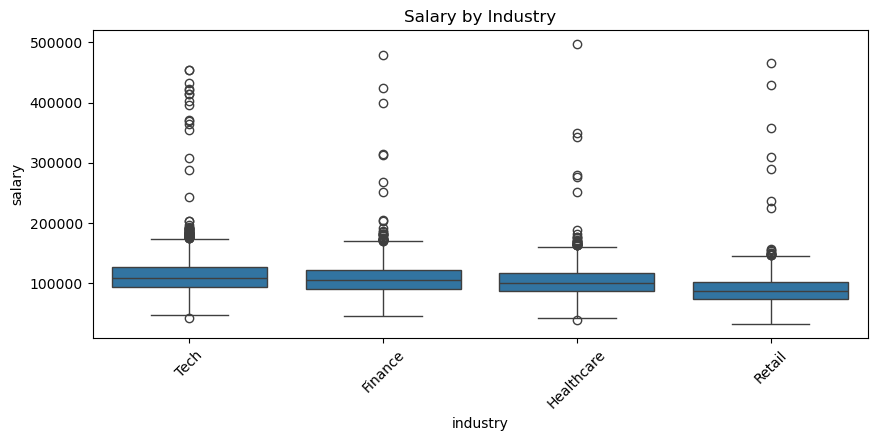

In [7]:
#Salary by industry
plt.figure(figsize=(10,4))
sns.boxplot(x='industry', y='salary', data=df)
plt.xticks(rotation=45)
plt.title("Salary by Industry")
plt.show()

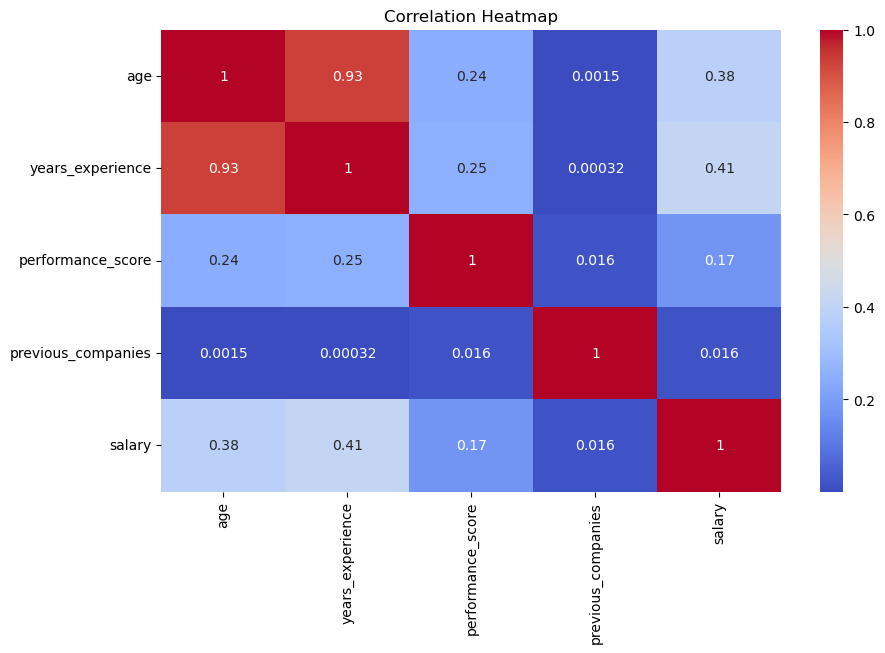

In [8]:
#Correlation heatmap (numeric features)
numeric_cols = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Q2

In [9]:
df.isnull().sum()

age                     0
gender                  0
education_level       115
years_experience      132
job_title               0
performance_score     254
industry                0
city                   60
previous_companies      0
remote_worker           0
salary                  0
dtype: int64

In [10]:
# Separate column types
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Fill missing numeric values with median
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill missing categorical values with mode
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_19048\1589817436.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_19048\1589817436.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, w

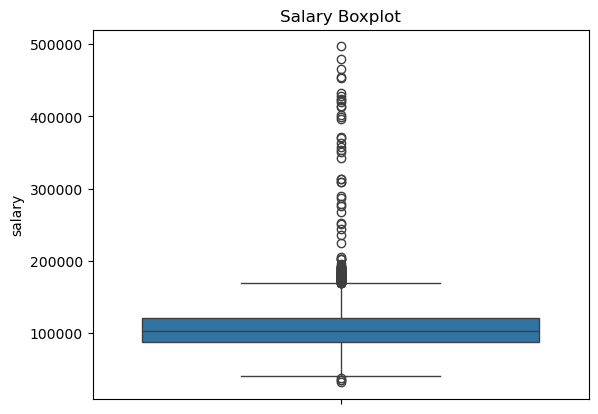

In [11]:
plt.figure()
sns.boxplot(y=df['salary'])
plt.title("Salary Boxplot")
plt.show()

In [12]:
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['salary'] = df['salary'].clip(lower, upper)

Salary outliers were handled using IQR-based capping to limit the influence of extreme values while retaining all observations. This prevents high-income outliers from disproportionately influencing coefficient estimates.

Q3

In [13]:
#Identify categorical columns
categorical_cols = [
    'gender',
    'education_level',
    'job_title',
    'industry',
    'city',
    'remote_worker'
]

In [14]:
#Apply One-Hot Encoding
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [15]:
#Separate X and y
X = df_encoded.drop(columns=['salary'])
y = df_encoded['salary']

Categorical variables were encoded using one-hot encoding because the categories are nominal and do not possess an inherent order. Dropping one category per feature avoids perfect multicollinearity.

Q4

In [16]:
# Reconstruct gender column for stratification
gender_cols = [col for col in df_encoded.columns if col.startswith('gender_')]

def get_gender(row):
    for col in gender_cols:
        if row[col] == 1:
            return col
    return 'gender_Male'  # reference category

gender_strata = df_encoded.apply(get_gender, axis=1)

In [17]:
#Perform stratified split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=gender_strata
)

In [18]:
#Verify stratification worked
print(gender_strata.value_counts(normalize=True))
print(pd.Series(gender_strata.loc[X_train.index]).value_counts(normalize=True))
print(pd.Series(gender_strata.loc[X_test.index]).value_counts(normalize=True))

gender_Male     0.982083
gender_Other    0.017917
Name: proportion, dtype: float64
gender_Male     0.982083
gender_Other    0.017917
Name: proportion, dtype: float64
gender_Male     0.982083
gender_Other    0.017917
Name: proportion, dtype: float64


The dataset was split into training and testing sets using stratified sampling based on gender, the protected attribute. This ensures that all gender groups are proportionally represented in both sets, enabling reliable evaluation of fairness metrics and preventing bias caused by underrepresentation of minority groups.

Q5

In [19]:
#Train the OLS model
from sklearn.linear_model import LinearRegression

# Initialize model
ols_model = LinearRegression()

# Train model
ols_model.fit(X_train, y_train)

LinearRegression()

In [20]:
#Make predictions
y_train_pred = ols_model.predict(X_train)
y_test_pred = ols_model.predict(X_test)

In [21]:
#Check model learned something
print("Train R^2:", ols_model.score(X_train, y_train))
print("Test R^2:", ols_model.score(X_test, y_test))

Train R^2: 0.8631815926375697
Test R^2: 0.8553682282130322


Q6

In [22]:
import numpy as np
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)

# Convert to numpy arrays explicitly
X_train_sm = np.asarray(X_train_sm, dtype=float)
y_train_sm = np.asarray(y_train, dtype=float)

In [23]:
ols_sm = sm.OLS(y_train_sm, X_train_sm).fit()
ols_sm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.863
Method:                 Least Squares   F-statistic:                     1587.
Date:                Sat, 13 Dec 2025   Prob (F-statistic):               0.00
Time:                        14:12:49   Log-Likelihood:            -1.0106e+05
No. Observations:                9600   AIC:                         2.022e+05
Df Residuals:                    9561   BIC:                         2.025e+05
Df Model:                          38                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.084e+04    989.232     51.398      0.000    4.89e+04    5.28e+04
x1           125.5520     31.906      3.935      0.000      63.010     188.094
x2          1169.3792     30.322     38.565      0.000    1109.941    1228.817
x3          2665.9509    124.070     21.487      0.000    2422.747    2909.155
x4           269.2843     66.301      4.062      0.000     139.320     399.249
x5          5193.1438    188.388     27.566      0.000    4823.863    5562.424
x6         -3212.7821    705.887     -4.551      0.000   -4596.470   -1829.095
x7         -1.315e+04    269.820    -48.733      0.000   -1.37e+04   -1.26e+04
x8          1.055e+04    224.046     47.079      0.000    1.01e+04     1.1e+04
x9          2.424e+04    439.851     55.112      0.000    2.34e+04    2.51e+04
x10         1.018e+04    507.639     20.059      0.000    9187.443    1.12e+04
x11         1.236e+04    511.109     24.184      0.000    1.14e+04    1.34e+04
x12        -5396.3543    517.925    -10.419      0.000   -6411.596   -4381.112
x13         1.155e+04    508.299     22.717      0.000    1.06e+04    1.25e+04
x14         7989.4089    512.589     15.586      0.000    6984.626    8994.191
x15        -1591.4635    511.574     -3.111      0.002   -2594.257    -588.669
x16        -3241.8478    516.862     -6.272      0.000   -4255.007   -2228.689
x17         5081.0400    523.052      9.714      0.000    4055.748    6106.332
x18         3512.6837    516.922      6.795      0.000    2499.408    4525.960
x19         9964.0049    513.934     19.388      0.000    8956.584     1.1e+04
x20        -5672.0942    515.155    -11.010      0.000   -6681.907   -4662.282
x21        -3150.3265    509.194     -6.187      0.000   -4148.455   -2152.198
x22          913.1205    511.331      1.786      0.074     -89.196    1915.437
x23         3112.4654    511.235      6.088      0.000    2110.336    4114.595
x24        -6472.1573    291.864    -22.175      0.000   -7044.272   -5900.043
x25        -1.791e+04    314.779    -56.897      0.000   -1.85e+04   -1.73e+04
x26         3210.4524    250.548     12.814      0.000    2719.325    3701.580
x27             1e+04    458.656     21.812      0.000    9105.267    1.09e+04
x28         2.151e+04    457.926     46.979      0.000    2.06e+04    2.24e+04
x29         5209.8745    463.455     11.241      0.000    4301.405    6118.344
x30         3301.6093    457.383      7.218      0.000    2405.043    4198.176
x31         9572.4636    466.280     20.529      0.000    8658.455    1.05e+04
x32          2.43e+04    457.697     53.089      0.000    2.34e+04    2.52e+04
x33         5409.9760    447.194     12.098      0.000    4533.380    6286.572
x34         3.793e+04    462.126     82.079      0.000     3.7e+04    3.88e+04
x35        -3948.9414    459.091     -8.602      0.000   -4848.858   -3049.025
x3

Q7

In [24]:
import pandas as pd

summary_df = pd.DataFrame({
    "Coefficient": ols_sm.params,
    "Std Error": ols_sm.bse,
    "p-value": ols_sm.pvalues
})

summary_df

,Coefficient,Std Error,p-value
0,50844.661680,989.231900,0.000000e+00
1,125.552033,31.905793,8.375581e-05
2,1169.379196,30.322290,1.501901e-302
3,2665.950866,124.070406,4.633328e-100
4,269.284301,66.301134,4.914055e-05
5,5193.143803,188.388114,4.986822e-161
6,-3212.782080,705.886614,5.394437e-06
7,-13149.025850,269.819638,0.000000e+00
8,10547.761508,224.045929,0.000000e+00
9,24241.109017,439.851321,0.000000e+00


In [25]:
#Identify the most influential coefficients
summary_df['abs_coef'] = summary_df['Coefficient'].abs()
top5 = summary_df.sort_values(by='abs_coef', ascending=False).head(5)
top5

,Coefficient,Std Error,p-value,abs_coef
0,50844.661680,989.231900,0.0,50844.661680
36,42277.528261,455.952709,0.0,42277.528261
34,37930.760385,462.125614,0.0,37930.760385
32,24298.697784,457.696530,0.0,24298.697784
9,24241.109017,439.851321,0.0,24241.109017


Q8

In [26]:
#Make predictions on the test set
y_test_pred = ols_model.predict(X_test)

In [27]:
#Compute RMSE, MAE, and 𝑅 squared
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R^2:", r2)

RMSE: 9056.521872620322
MAE: 6785.295644348116
R^2: 0.8553682282130322


Q9

In [28]:
#Compute residuals and fitted values
# Fitted values
y_test_hat = y_test_pred

# Residuals
residuals = y_test - y_test_hat

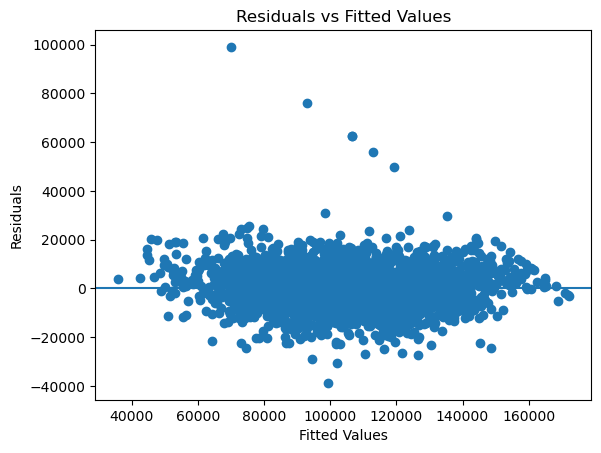

In [29]:
#Residuals vs Fitted Values (Linearity + Homoscedasticity)
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test_hat, residuals)
plt.axhline(0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

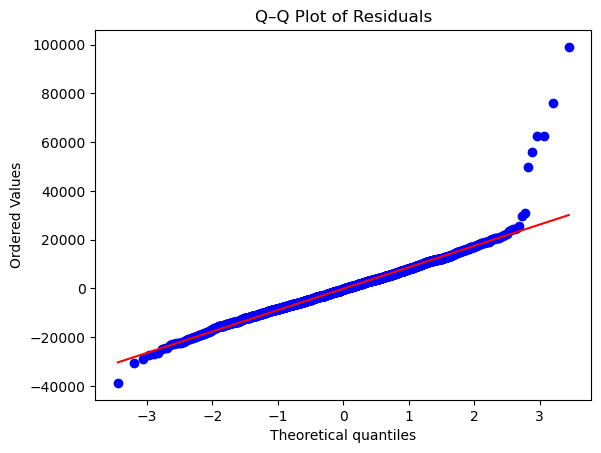

In [30]:
#Q–Q Plot (Normality)
import scipy.stats as stats

plt.figure()
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q–Q Plot of Residuals")
plt.show()

Diagnostic plots were used to assess linear regression assumptions. The residuals versus fitted values plot shows a random scatter around zero with no systematic pattern, suggesting that the linearity and homoscedasticity assumptions are reasonably satisfied. The Q–Q plot of residuals shows points lying approximately along the reference line, indicating that the residuals are approximately normally distributed. Overall, the linear regression assumptions appear to hold for this model.

Q10

In [31]:
import numpy as np
from sklearn.metrics import mean_absolute_error
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
#Setup (true values, predictions, gender labels)
y_true = y_test.values.flatten()
y_pred = y_test_pred.flatten()

gender_test = gender_strata.loc[X_test.index].values

male_mask = (gender_test == 'gender_Male')
female_mask = (gender_test == 'gender_Female')
other_mask = (gender_test == 'gender_Other')

print("Group sizes:")
print("Male:", male_mask.sum())
print("Female:", female_mask.sum())
print("Other:", other_mask.sum())

Group sizes:
Male: 2357
Female: 0
Other: 43


In [33]:
#Utility functions
def safe_mean(arr, name):
    if arr.size == 0:
        print(f"{name}: No samples")
        return None
    return arr.mean()

def safe_mae(y_true, y_pred, mask, name):
    if mask.sum() == 0:
        print(f"{name}: No samples")
        return None
    return mean_absolute_error(y_true[mask], y_pred[mask])

In [34]:
#Mean Salary Prediction Difference
mean_pred_male = safe_mean(y_pred[male_mask], "Male")
mean_pred_female = safe_mean(y_pred[female_mask], "Female")
mean_pred_other = safe_mean(y_pred[other_mask], "Other")

diff_male_female = (
    mean_pred_male - mean_pred_female
    if mean_pred_female is not None else None
)

diff_male_other = (
    mean_pred_male - mean_pred_other
    if mean_pred_other is not None else None
)

print("\nMean Salary Prediction Difference:")
print("Male - Female:", diff_male_female)
print("Male - Other:", diff_male_other)

Female: No samples

Mean Salary Prediction Difference:
Male - Female: None
Male - Other: 3097.1726478709315


In [35]:
#Mean Absolute Error (MAE) per group
mae_male = safe_mae(y_true, y_pred, male_mask, "Male")
mae_female = safe_mae(y_true, y_pred, female_mask, "Female")
mae_other = safe_mae(y_true, y_pred, other_mask, "Other")

print("\nMAE per group:")
print("Male:", mae_male)
print("Female:", mae_female)
print("Other:", mae_other)

Female: No samples

MAE per group:
Male: 6807.629452089979
Female: None
Other: 5561.091345567413


In [36]:
#Demographic Parity Difference (DPD)
threshold = np.median(y_pred)

def safe_rate(mask, name):
    if mask.sum() == 0:
        print(f"{name}: No samples")
        return None
    return (y_pred[mask] > threshold).mean()

dp_male = safe_rate(male_mask, "Male")
dp_female = safe_rate(female_mask, "Female")
dp_other = safe_rate(other_mask, "Other")

dpd_male_female = dp_male - dp_female if dp_female is not None else None
dpd_male_other = dp_male - dp_other if dp_other is not None else None

print("\nDemographic Parity Difference:")
print("Male - Female:", dpd_male_female)
print("Male - Other:", dpd_male_other)

Female: No samples

Demographic Parity Difference:
Male - Female: None
Male - Other: 0.035520123136426884


In [37]:
#Equal Opportunity Difference (EOD)
true_threshold = np.median(y_true)

def safe_tpr(mask, name):
    if mask.sum() == 0:
        print(f"{name}: No samples")
        return None
    return ((y_pred[mask] > threshold) & (y_true[mask] > true_threshold)).mean()

tpr_male = safe_tpr(male_mask, "Male")
tpr_female = safe_tpr(female_mask, "Female")
tpr_other = safe_tpr(other_mask, "Other")

eod_male_female = tpr_male - tpr_female if tpr_female is not None else None
eod_male_other = tpr_male - tpr_other if tpr_other is not None else None

print("\nEqual Opportunity Difference:")
print("Male - Female:", eod_male_female)
print("Male - Other:", eod_male_other)

Female: No samples

Equal Opportunity Difference:
Male - Female: None
Male - Other: 0.02984677013546977


In [38]:
#Predictive Equality (False Positive Rate)
def safe_fpr(mask, name):
    if mask.sum() == 0:
        print(f"{name}: No samples")
        return None
    return ((y_pred[mask] > threshold) & (y_true[mask] <= true_threshold)).mean()

fpr_male = safe_fpr(male_mask, "Male")
fpr_female = safe_fpr(female_mask, "Female")
fpr_other = safe_fpr(other_mask, "Other")

print("\nPredictive Equality (FPR):")
print("Male:", fpr_male)
print("Female:", fpr_female)
print("Other:", fpr_other)

Female: No samples

Predictive Equality (FPR):
Male: 0.05218498090793382
Female: None
Other: 0.046511627906976744


In [39]:
#Disparate Impact Ratio (DIR)
dir_female = dp_female / dp_male if dp_female is not None else None
dir_other = dp_other / dp_male if dp_other is not None else None

print("\nDisparate Impact Ratio:")
print("Female / Male:", dir_female)
print("Other / Male:", dir_other)


Disparate Impact Ratio:
Female / Male: None
Other / Male: 0.9290500591249508


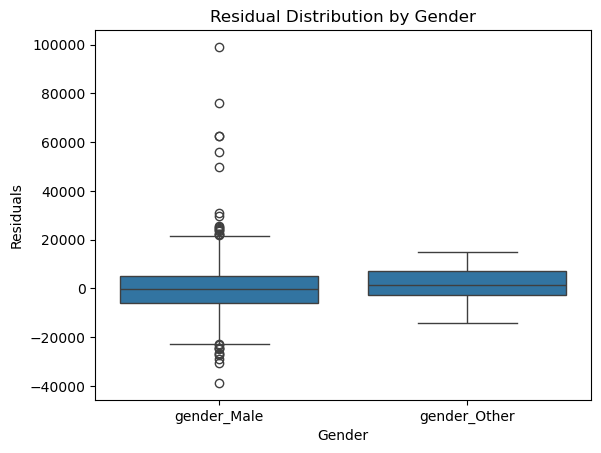

In [40]:
#Residual Distribution by Gender (plot)
residuals = y_true - y_pred

plt.figure()
sns.boxplot(x=gender_test, y=residuals)
plt.title("Residual Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Residuals")
plt.show()

Q11

In [41]:
#Prepare residuals by group
from scipy.stats import ttest_ind

residuals = y_true - y_pred

res_male = residuals[male_mask]
res_female = residuals[female_mask]
res_other = residuals[other_mask]

print("Residual counts:")
print("Male:", res_male.size)
print("Female:", res_female.size)
print("Other:", res_other.size)

Residual counts:
Male: 2357
Female: 0
Other: 43


In [42]:
#Run t-tests (Male vs Female, Male vs Other)
def safe_ttest(a, b, name_a, name_b):
    if a.size == 0 or b.size == 0:
        print(f"{name_a} vs {name_b}: Not enough samples for t-test")
        return None
    t_stat, p_val = ttest_ind(a, b, equal_var=False)
    print(f"{name_a} vs {name_b}: t = {t_stat:.3f}, p = {p_val:.4f}")
    return t_stat, p_val

print("\nT-test results:")
ttest_male_female = safe_ttest(res_male, res_female, "Male", "Female")
ttest_male_other = safe_ttest(res_male, res_other, "Male", "Other")


T-test results:
Male vs Female: Not enough samples for t-test
Male vs Other: t = -2.033, p = 0.0481


The t-test comparing residuals between Male and Female groups could not be conducted due to the absence of Female samples in the test set, reflecting severe underrepresentation of this group

The t-test comparing residuals for the Male and Other groups is statistically significant (p = 0.0481), indicating that the model’s prediction errors differ systematically between these groups. This means the model does not make similar errors for Male and Other employees and tends to overestimate or underestimate salaries differently for the Other group relative to males, suggesting potential bias.

Q12

In [43]:
mean_res_male = residuals[male_mask].mean()
mean_res_other = residuals[other_mask].mean()

mean_res_male, mean_res_other

(np.float64(-182.47273992276195), np.float64(1975.4775175178945))

The model tends to underestimate salaries for the Other gender group relative to males, indicating systematic underprediction for this group.

Q13 

In [44]:
!pip install shap

   ---------------------------------------- 0.0/549.1 kB ? eta -:--:--
   ---------------------------------------- 549.1/549.1 kB 8.2 MB/s eta 0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [45]:
import shap
import numpy as np
import matplotlib.pyplot as plt

In [53]:
# Convert training data to numpy
X_test_np = np.asarray(X_test, dtype=float)
X_train_np = np.asarray(X_train, dtype=float)

# SHAP explainer
explainer = shap.LinearExplainer(
    ols_model,
    X_train_np,
    feature_names=X_train.columns
)

shap_values = explainer.shap_values(X_test_np)

In [54]:
shap_values = explainer.shap_values(X_test_np)
shap_values.shape

(2400, 38)

In [55]:
feature_names = X_train.columns

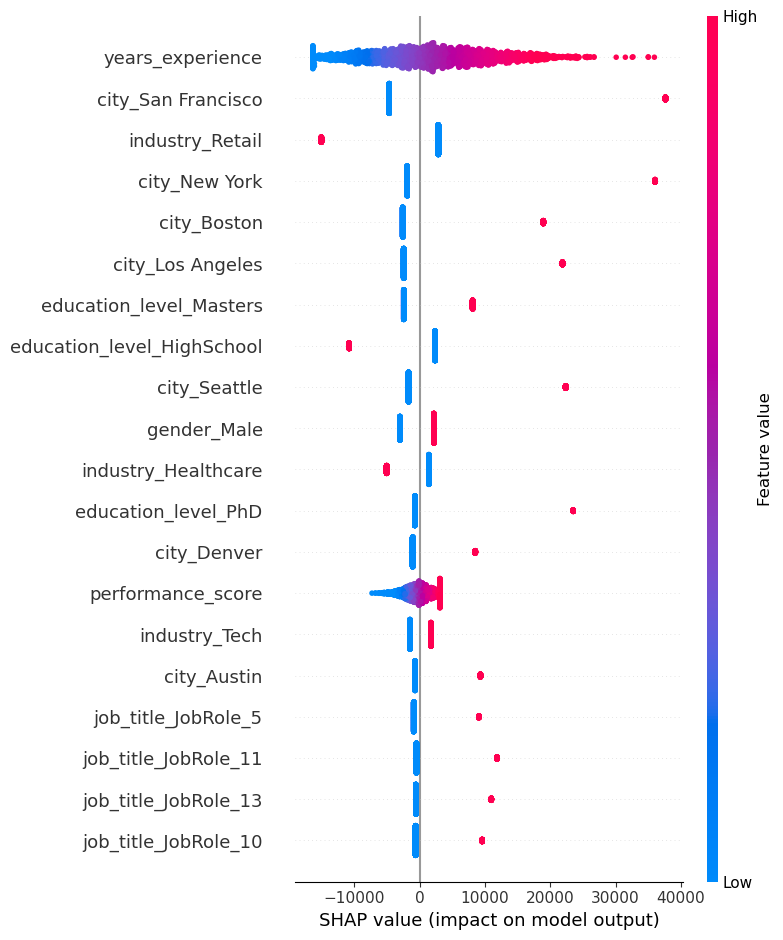

In [56]:
shap.summary_plot(
    shap_values,
    X_test_np,
    feature_names=X_train.columns
)

In [58]:
# Mean absolute SHAP value per feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)

top_features = X_train.columns[np.argsort(mean_abs_shap)[-3:]]
top_features

Index(['industry_Retail', 'city_San Francisco', 'years_experience'], dtype='object')

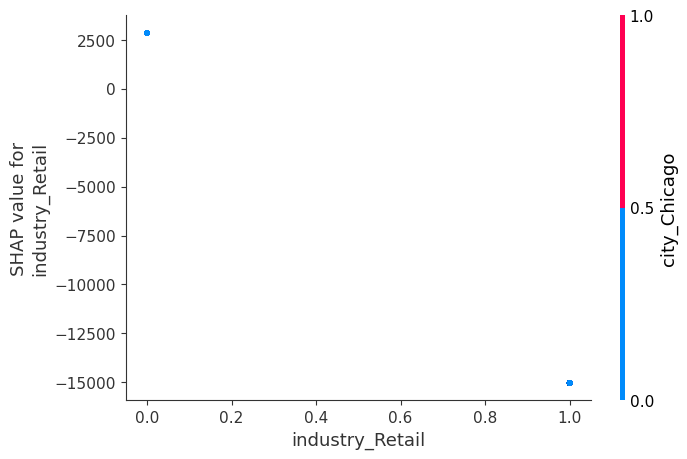

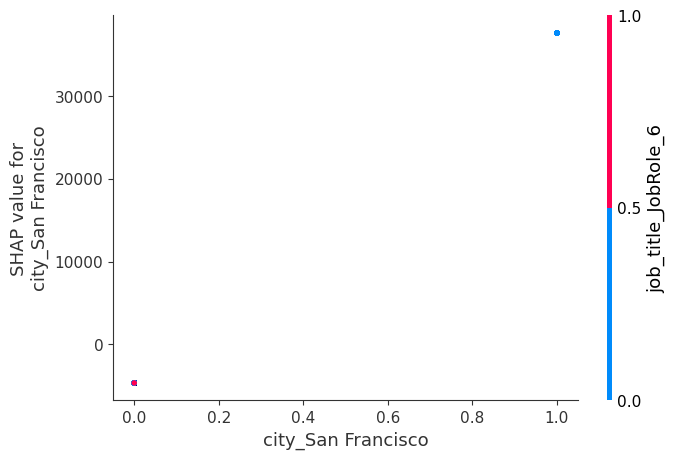

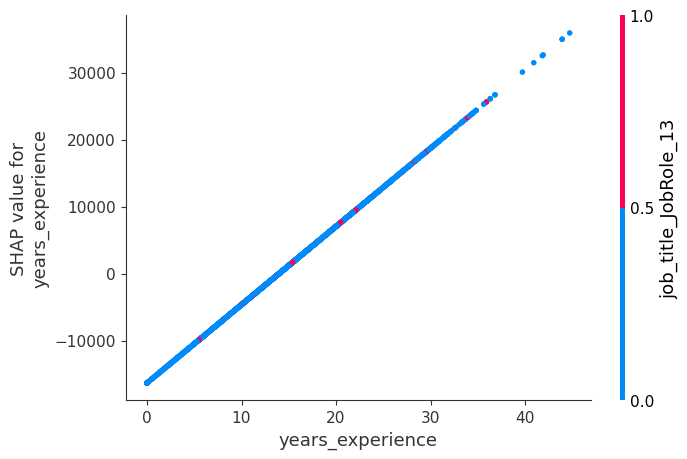

In [59]:
for feature in top_features:
    shap.dependence_plot(
        feature,
        shap_values,
        X_test_np,
        feature_names=X_train.columns
    )

The SHAP summary plot indicates that years of experience is the most influential feature driving salary predictions, followed by location, education level, and job-related variables. Higher experience and advanced education substantially increase predicted salary, while retail industry affiliation reduces it.
Dependence plots show a strong linear relationship between experience and salary, and significant positive effects for high-paying cities such as San Francisco. The presence of a positive SHAP contribution for the male gender variable suggests potential gender-related bias in model predictions.